# 🏍️ SegFormer-B1 + YOLOv8-Seg 하이브리드

## 핵심 아이디어

| 모델 | 담당 클래스 | 이유 |
|------|------------|------|
| **SegFormer-B0** (경량, 3.7M) | Undrivable, Road, Lane Mark | 배경 시맨틱 세그. 선형/연속 영역에 강함 |
| **YOLOv8n-Seg** (경량, 3.4M) | My bike, Rider, Moveable | 인스턴스 세그 + 실시간 탐지 |

## 왜 B0?

- **B2 (27.4M) → B1 (14M)**: 2배 경량화
- YOLO(3.4M)와 합쳐도  — 단일 B2보다 가벼움
- T4에서 batch=8 가능, 추론도 빠름
- 실제 HUD(Jetson/엣지) 이식 가능성 고려

## 융합 전략

```
이미지 → SegFormer-B0 → 배경 3클래스 마스크
      ↘
        YOLOv8-Seg → 객체 3클래스 마스크
                              ↓
                     [우선순위 융합]
                     객체 픽셀 > 배경 픽셀
                              ↓
                    최종 6클래스 마스크
```

**실행 환경:** T4 GPU, 약 40분 소요

# 📦 Part 1: 환경 설치

In [1]:
!pip install kaggle pycocotools albumentations imageio imageio-ffmpeg -q
!pip install transformers accelerate -q              # SegFormer
!pip install ultralytics -q                          # YOLOv8

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# kaggle.json 업로드 후:
# !cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print('✅ 설치 완료')

✅ 설치 완료


In [2]:
import torch, numpy as np, json, os, shutil
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'메모리: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB')

Device: cuda
GPU: Tesla T4
메모리: 14.6 GB


# 🗂️ Part 2: 데이터 준비

In [3]:
if not os.path.exists('./data'):
    !kaggle datasets download -d sadhliroomyprime/motorcycle-night-ride-semantic-segmentation
    !unzip -q motorcycle-night-ride-semantic-segmentation.zip -d ./motorcycle_data
    !ln -sf "./motorcycle_data/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset" ./data
print('✅ 데이터 준비 완료')

✅ 데이터 준비 완료


In [4]:
from pycocotools.coco import COCO

DATA_ROOT   = './data'
IMAGES_DIR  = os.path.join(DATA_ROOT, 'images')
MASKS_DIR   = os.path.join(DATA_ROOT, 'masks_generated')
JSON_PATH   = os.path.join(DATA_ROOT, 'COCO_motorcycle (pixel).json')

CLASS_NAMES = ['Undrivable', 'Road', 'Lane Mark', 'My bike', 'Rider', 'Moveable']
NUM_CLASSES = 6

# SEGFORMER: 배경, 정적인 경계, 객체 탐지
# YOLO: 객체 추척
# 병렬로 객체의 특성에 맞게 학습 후 합침
SEGFORMER_CLASSES = [0, 1, 2]  # 배경: Undrivable, Road, Lane Mark
YOLO_CLASSES      = [3, 4, 5]  # 객체: My bike, Rider, Moveable

CATEGORY_MAPPING = {
    1323880: 0, 1323881: 1, 1323882: 2,
    1323885: 3, 1329681: 4, 1323884: 5,
}

COLORS = np.array([
    [128,128,128], [64,64,64], [255,255,0],
    [0,0,255],     [255,0,0],  [0,255,0]
], dtype=np.uint8)

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    coco_json = json.load(f)
coco_api = COCO(JSON_PATH)
print(f'이미지: {len(coco_json["images"])}장')
print(f'SegFormer 담당: {[CLASS_NAMES[i] for i in SEGFORMER_CLASSES]}')
print(f'YOLO 담당: {[CLASS_NAMES[i] for i in YOLO_CLASSES]}')

loading annotations into memory...
Done (t=2.31s)
creating index...
index created!
이미지: 200장
SegFormer 담당: ['Undrivable', 'Road', 'Lane Mark']
YOLO 담당: ['My bike', 'Rider', 'Moveable']


In [5]:
# COCO는 MASK 정보 호팜이 가능
# https://walkaroundthedevelop.tistory.com/133
def get_mask_for_image(image_id):
    img_info = coco_api.loadImgs(image_id)[0]
    H, W = img_info['height'], img_info['width']
    mask = np.full((H, W), 255, dtype=np.uint8)
    ann_ids = coco_api.getAnnIds(imgIds=image_id)
    anns = sorted(coco_api.loadAnns(ann_ids), key=lambda x: x['area'], reverse=True)
    for ann in anns:
        cat_id = ann['category_id']
        if cat_id not in CATEGORY_MAPPING:
            continue
        binary = coco_api.annToMask(ann)
        mask[binary == 1] = CATEGORY_MAPPING[cat_id]
    return mask, img_info['file_name']

os.makedirs(MASKS_DIR, exist_ok=True)
if len(os.listdir(MASKS_DIR)) < len(coco_api.getImgIds()):
    print('마스크 생성 중...')
    for img_id in tqdm(coco_api.getImgIds()): # COCO 데이터셋에서 이미지 ID 목록에 대한 반복 작업 진행 상황을 진행바(Progress Bar)로 시각화
        mask, fname = get_mask_for_image(img_id)
        Image.fromarray(mask).save(os.path.join(MASKS_DIR, fname))
print('✅ 마스크 준비 완료')

# Train/Val 분할 (두 모델 공통)
# Train이 80%, Val 20e%
all_filenames   = [img['file_name'] for img in coco_json['images']]
valid_filenames = [fn for fn in all_filenames
                   if os.path.exists(os.path.join(IMAGES_DIR, fn))
                   and os.path.exists(os.path.join(MASKS_DIR,  fn))]
np.random.seed(42)
shuffled    = np.random.permutation(valid_filenames)
split_idx   = int(len(shuffled) * 0.8)
train_files = shuffled[:split_idx].tolist()
val_files   = shuffled[split_idx:].tolist()
print(f'Train: {len(train_files)}장, Val: {len(val_files)}장')

✅ 마스크 준비 완료
Train: 160장, Val: 40장


# 🎯 Part 3: YOLO용 데이터 변환

YOLO는 마스크가 아닌 **polygon 포맷** 라벨을 요구.
객체 클래스(3,4,5)만 추출 → 정규화된 polygon으로 변환.

In [6]:
YOLO_ROOT = './yolo_data'
for split in ['train', 'val']:
    os.makedirs(f'{YOLO_ROOT}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_ROOT}/labels/{split}', exist_ok=True)

'''
dst, contours, hierarchy = cv2.findContours(src, mode, method, contours, hierarchy, offset)
컨투어(contour)는 등고선을 의미합니다. 등고선은 지형의 높이가 같은 영역을 하나의 선으로 표시한 것
src: 입력 영상, 검정과 흰색으로 구성된 바이너리 이미지
mode: 컨투어 제공 방식 (cv2.RETR_EXTERNAL: 가장 바깥쪽 라인만 생성, cv2.RETR_LIST: 모든 라인을 계층 없이 생성, cv2.RET_CCOMP: 모든 라인을 2 계층으로 생성, cv2.RETR_TREE: 모든 라인의 모든 계층 정보를 트리 구조로 생성)
method: 근사 값 방식 (cv2.CHAIN_APPROX_NONE: 근사 없이 모든 좌표 제공, cv2.CHAIN_APPROX_SIMPLE: 컨투어 꼭짓점 좌표만 제공, cv2.CHAIN_APPROX_TC89_L1: Teh-Chin 알고리즘으로 좌표 개수 축소, cv2.CHAIN_APPROX_TC89_KCOS: Teh-Chin 알고리즘으로 좌표 개수 축소)
contours(optional): 검출한 컨투어 좌표 (list type)
hierarchy(optional): 컨투어 계층 정보 (Next, Prev, FirstChild, Parent, -1 [해당 없음])
offset(optional): ROI 등으로 인해 이동한 컨투어 좌표의 오프셋
'''

def mask_to_yolo_polygons(mask, target_classes):
    """
    세그멘테이션 마스크 → YOLO polygon 라벨
    target_classes: 원본 클래스 ID 리스트 [3, 4, 5]
    반환: 'class_idx x1 y1 x2 y2 ...' 형식 문자열 리스트
    """
    H, W = mask.shape
    labels = []
    for yolo_idx, orig_cls in enumerate(target_classes):
        binary = (mask == orig_cls).astype(np.uint8)
        if binary.sum() < 100:
            continue
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if cv2.contourArea(contour) < 50:
                continue
            epsilon = 0.002 * cv2.arcLength(contour, True) # 전체 둘레의 0.002로 오차 범위 지정
            approx  = cv2.approxPolyDP(contour, epsilon, True) # 근사 컨투어 계산
            if len(approx) < 3:
                continue
            pts = approx.reshape(-1, 2).astype(np.float32)
            pts[:, 0] /= W
            pts[:, 1] /= H
            pts = np.clip(pts, 0, 1)
            coords = ' '.join([f'{p:.6f}' for p in pts.flatten()])
            labels.append(f'{yolo_idx} {coords}')
    return labels


def prepare_yolo_split(file_list, split_name):
    n_with_labels = 0
    for fname in tqdm(file_list, desc=f'YOLO {split_name}'):
        src_img = os.path.join(IMAGES_DIR, fname)
        dst_img = os.path.join(YOLO_ROOT, 'images', split_name, fname)
        if not os.path.exists(dst_img):
            shutil.copy2(src_img, dst_img)

        mask = np.array(Image.open(os.path.join(MASKS_DIR, fname)))
        mask[mask == 255] = 0
        labels = mask_to_yolo_polygons(mask, YOLO_CLASSES)

        label_fname = os.path.splitext(fname)[0] + '.txt'
        label_path  = os.path.join(YOLO_ROOT, 'labels', split_name, label_fname)
        with open(label_path, 'w') as f:
            f.write('\n'.join(labels))
        if labels:
            n_with_labels += 1
    print(f'  {n_with_labels}/{len(file_list)}장에 객체 라벨 생성됨')


prepare_yolo_split(train_files, 'train')
prepare_yolo_split(val_files,   'val')

# data.yaml 생성 (YOLO 학습 설정 파일)
yolo_yaml = f"""\
path: {os.path.abspath(YOLO_ROOT)}
train: images/train
val: images/val

nc: {len(YOLO_CLASSES)}
names:
  0: My_bike
  1: Rider
  2: Moveable
"""
with open(f'{YOLO_ROOT}/data.yaml', 'w') as f:
    f.write(yolo_yaml)
print(f'\n✅ YOLO 데이터 준비 완료 ({YOLO_ROOT}/data.yaml)')

YOLO train: 100%|██████████| 160/160 [00:03<00:00, 40.81it/s]


  160/160장에 객체 라벨 생성됨


YOLO val: 100%|██████████| 40/40 [00:01<00:00, 39.25it/s]

  40/40장에 객체 라벨 생성됨

✅ YOLO 데이터 준비 완료 (./yolo_data/data.yaml)


# 🤖 Part 4: SegFormer-B0 (배경 3클래스)

B0 = 가장 경량 버전. 파라미터 3.7M, 기존 B2 대비 7배 가볍다.

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

IMG_H, IMG_W = 512, 512

train_transform = A.Compose([
    A.Resize(height=IMG_H, width=IMG_W),
    A.HorizontalFlip(p=0.5),
    A.RandomGamma(gamma_limit=(60, 140), p=0.4),
    A.RGBShift(r_shift_limit=15, g_shift_limit=10, b_shift_limit=20, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=IMG_H, width=IMG_W),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])


class MotorcycleBackgroundDataset(Dataset):
    """
    SegFormer 전용 데이터셋: 객체 픽셀(3,4,5)을 0(Undrivable)으로 합쳐서 3클래스만 남김
    0: Undrivable(+객체 영역 통합), 1: Road, 2: Lane Mark
    """
    def __init__(self, file_list, images_dir, masks_dir, transform=None):
        self.file_list  = file_list
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.transform  = transform

    def __len__(self): return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        image = np.array(Image.open(os.path.join(self.images_dir, fname)).convert('RGB'))
        mask  = np.array(Image.open(os.path.join(self.masks_dir,  fname)))
        mask[mask == 255] = 0
        # 객체 클래스를 Undrivable(0)로 통합 → 배경 3클래스만
        mask[(mask == 3) | (mask == 4) | (mask == 5)] = 0

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].long()
        return image, mask


def cutmix_batch(images, masks, alpha=1.0):
    B, C, H, W = images.shape
    lam = np.random.beta(alpha, alpha)
    rand_idx  = torch.randperm(B)
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, y1 = max(0, cx - cut_w//2), max(0, cy - cut_h//2)
    x2, y2 = min(W, cx + cut_w//2), min(H, cy + cut_h//2)

    mixed_i = images.clone()
    mixed_m = masks.clone()
    mixed_i[:, :, y1:y2, x1:x2] = images[rand_idx, :, y1:y2, x1:x2]
    mixed_m[:,    y1:y2, x1:x2] = masks[rand_idx,    y1:y2, x1:x2]
    return mixed_i, mixed_m


BATCH_SIZE = 8  # B0는 가벼워서 B2(4) 대비 2배 가능
train_bg_dataset = MotorcycleBackgroundDataset(train_files, IMAGES_DIR, MASKS_DIR, train_transform)
val_bg_dataset   = MotorcycleBackgroundDataset(val_files,   IMAGES_DIR, MASKS_DIR, val_transform)
train_bg_loader  = DataLoader(train_bg_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
val_bg_loader    = DataLoader(val_bg_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)
print(f'✅ 배경 데이터셋 준비 (3클래스: Undrivable, Road, Lane Mark)')
print(f'   Batch: {BATCH_SIZE} (B0 경량화 덕분에 2배 가능)')

✅ 배경 데이터셋 준비 (3클래스: Undrivable, Road, Lane Mark)
   Batch: 8 (B0 경량화 덕분에 2배 가능)


In [8]:
from transformers import SegformerForSemanticSegmentation

BG_NUM_CLASSES = 3  # 배경만

segformer = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b1',              # ⭐ B0 사용->b1 으로 변경
    num_labels=BG_NUM_CLASSES,
    ignore_mismatched_sizes=True,
).to(device)

'''
F.interpolate
모델의 출력(logits) 크기를 목표 크기(target_size)로 조정(Resizing)하는 데 사용되는 일반적인 이미지 업샘플링(Upsampling) 방식
주로 시맨틱 세그멘테이션(Semantic Segmentation) 작업에서 모델이 내놓은 작은 크기의 특징 맵(Feature Map)을 입력 이미지 크기로 되돌릴 때 사용
outputs.logits: 모델이 출력한 텐서입니다. 일반적으로 [batch_size, num_classes, height, width] 형태를 가집니다.
size=target_size: 최종적으로 조정하고자 하는 목표 해상도입니다. (height, width) 형태의 튜플이나 단일 정수 값을 받습니다.
mode='bilinear': 쌍선형 보간법(Bilinear Interpolation)을 사용하여 픽셀 사이의 값을 계산합니다. 가장자리 값을 부드럽게 처리하여 이미지 업샘플링에 적합합니다.
align_corners=False: 픽셀 중심에 맞춰 정렬하는 방식입니다. False로 설정하면 입력과 출력 텐서의 가장자리 픽셀(corner pixels)이 일치하지 않을 수 있지만, 대개 픽셀 간격 정렬이 더 합리적이어서 대부분의 세그멘테이션 모델에서 추천되는 설정입니다. 
PyTorch documentation
PyTorch documentation
 +4
'''
def get_seg_logits(outputs, target_size):
    return F.interpolate(outputs.logits, size=target_size, mode='bilinear', align_corners=False)

total = sum(p.numel() for p in segformer.parameters())
print(f'SegFormer-B1 파라미터: {total:,} ({total/1e6:.2f}M)')
print('(참고: B2는 27.4M — 7배 가벼움)')

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

SegFormer-B1 파라미터: 13,678,019 (13.68M)
(참고: B2는 27.4M — 7배 가벼움)


# 🎯 Part 5: Lovász + CE Loss
- Jaccard loss(자카드 손실)는 1에서 Jaccard Index(IoU, Intersection over Union)를 뺀 값으로, 이미지 분할(Segmentation) 모델의 성능을 향상시키기 위해 사용하는 손실 함수
- Jaccard 인덱스는 곧 IoU를 의미
- 일반적인 Cross Entropy는 픽셀 하나하나의 정답 여부
- 하지만 Jaccard Loss는 이미지 전체의 객체 영역(IoU)을 고려하기 때문에, 배경에 비해 아주 작은 객체를 검출해야 할 때 훨씬 더 강력한 성능을 발휘.
- lovasz_grad 함수는 이 Jaccard Loss를 더 정교하게 최적화하기 위해 Lovász extension이라는 수학적 기법을 적용한 고급 버전

 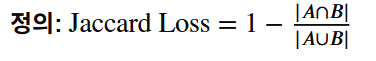  

 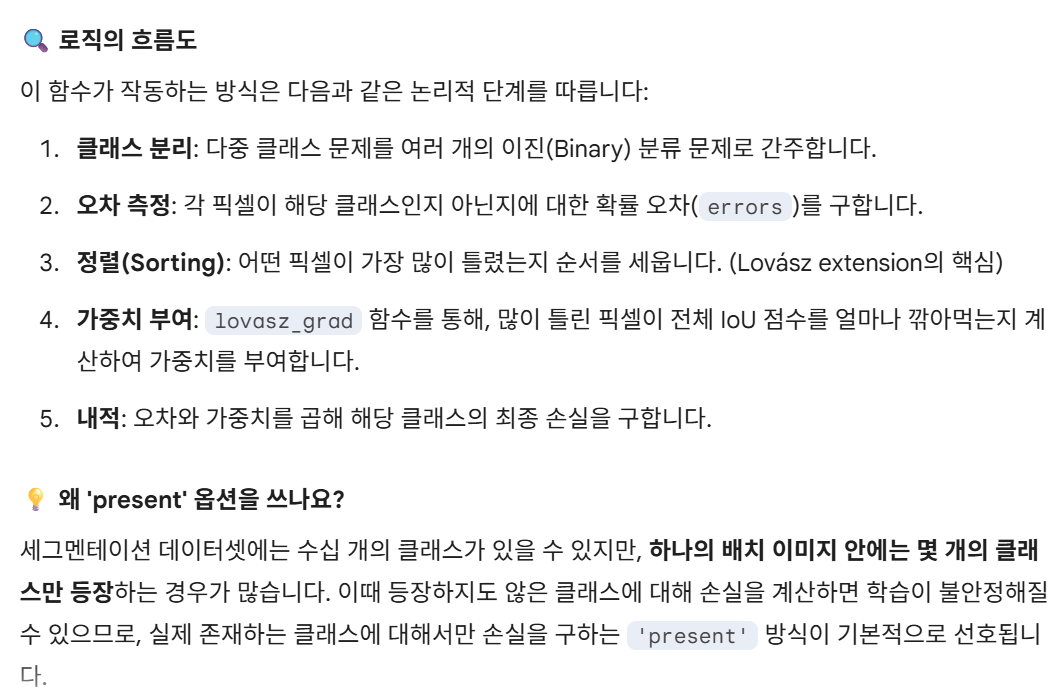

In [9]:
def lovasz_grad(gt_sorted):
    """
    정렬된 그라운드 트루스(GT) 벡터를 바탕으로 Lovász extension의 그라디언트를 계산합니다.
    이 과정은 주로 IoU(Jaccard index)를 최적화하기 위한 대리 손실 함수(surrogate loss) 계산에 사용됩니다.
    
    Args:
        gt_sorted (Tensor): 성능 저하 순서(오류가 큰 순서)로 정렬된 바이너리 레이블 (0 또는 1)
    """
    p = len(gt_sorted)
    gts = gt_sorted.sum() # GT 내의 양성(Positive) 샘플 총 개수
    
    # 누적 합(cumsum)을 이용하여 각 지점에서의 Intersection과 Union을 효율적으로 계산합니다.
    # intersection: 현재 지점 이후에 남아있는 양성 샘플의 수
    intersection = gts - gt_sorted.float().cumsum(0)
    
    # union: 현재 지점 이후의 양성 샘플 수 + 현재 지점까지의 음성(Negative) 샘플 수
    union = gts + (1 - gt_sorted).float().cumsum(0)
    
    # Jaccard distance 계산 (1 - IoU)
    # IoU = intersection / union 이므로, 이를 1에서 빼서 손실 값의 기초로 삼습니다.
    jaccard = 1. - intersection / union
    
    # p가 1보다 클 경우, 인접한 Jaccard 값들의 차이를 계산하여 그라디언트를 구합니다.
    # 이는 소위 'Lovász extension'에서 가중치를 할당하는 방식입니다.
    if p > 1:
        # jaccard[i] = jaccard[i] - jaccard[i-1] 형태의 차분 계산
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
        
    return jaccard


def flatten_probas(probas, labels, ignore=None):
    """
    다차원 확률 텐서와 레이블 텐서를 1차원으로 평탄화하고, 
    ignore 인덱스에 해당하는 픽셀을 제거합니다.
    
    Args:
        probas (Tensor): 모델의 출력 확률값 (B, C, H, W) 또는 (C, H, W)
        labels (Tensor): 그라운드 트루스 레이블 (B, H, W) 또는 (H, W)
        ignore (int, optional): 무시할 클래스 인덱스 (학습에서 제외할 영역)
    """
    # 1. 차원 맞추기: 3D 데이터(C, H, W)가 들어오면 배치(B) 차원을 추가하여 4D로 통일
    if probas.dim() == 3:
        probas = probas.unsqueeze(0)
    if labels.dim() == 2:
        labels = labels.unsqueeze(0)
        
    B, C, H, W = probas.size()
    
    # 2. 확률 텐서 재배치: (B, C, H, W) -> (B, H, W, C) -> (B*H*W, C)
    # 각 픽셀 위치에서 클래스별 확률(C)을 한 줄로 나열함
    probas = probas.permute(0, 2, 3, 1).contiguous().view(-1, C)
    
    # 3. 레이블 텐서 평탄화: (B, H, W) -> (B*H*W)
    labels = labels.view(-1)
    
    # 4. 유효 데이터 필터링: ignore 인덱스가 설정된 경우 해당 픽셀들을 제외
    if ignore is not None:
        valid = labels != ignore     # ignore가 아닌 픽셀만 True인 마스크 생성
        probas = probas[valid]       # 유효한 픽셀의 확률값만 추출
        labels = labels[valid]       # 유효한 픽셀의 레이블만 추출
        
    return probas, labels
    
def lovasz_softmax_flat(probas, labels, classes='present'):
    if probas.numel() == 0:
        return probas * 0.
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes == 'all' else torch.unique(labels).tolist()
    for c in class_to_sum:
        fg = (labels == c).float()
        if fg.sum() == 0 and classes == 'present':
            continue
        class_pred = probas[:, c]
        errors     = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm.data]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0, device=probas.device)

def lovasz_softmax_flat(probas, labels, classes='present'):
    """
    평탄화된 확률값과 레이블을 입력받아 Lovász-Softmax 손실을 계산합니다.
    
    Args:
        probas (Tensor): [픽셀 수, 클래스 수] 형태의 확률값 (Softmax 결과)
        labels (Tensor): [픽셀 수] 형태의 정답 레이블
        classes (str): 'all' (모든 클래스 계산) 또는 'present' (데이터에 존재하는 클래스만 계산)

        flatten_probas와 lovasz_grad를 하나로 묶어, 실제로 다중 클래스(Multi-class) Lovász-Softmax Loss를 계산하는 핵심 루틴
        각 클래스별로 에러(Error)를 계산하고, 이를 정렬하여 Lovász extension 가중치와 내적(Dot product)함으로써 최종 손실값을 산출
    """
    # 0. 예외 처리: 입력 데이터가 비어있을 경우 0 반환
    if probas.numel() == 0:
        return probas * 0.
        
    C = probas.size(1) # 클래스 개수
    losses = []
    
    # 1. 계산할 클래스 결정
    # 'all'이면 모든 클래스(0~C-1), 'present'면 현재 배치에 실제 존재하는 클래스만 선택
    class_to_sum = list(range(C)) if classes == 'all' else torch.unique(labels).tolist()
    
    for c in class_to_sum:
        # 2. 특정 클래스 c에 대한 바이너리 마스크 (Foreground 생성)
        fg = (labels == c).float() 
        
        # 'present' 모드일 때 해당 클래스가 현재 배치에 없다면 계산 건너띔
        if fg.sum() == 0 and classes == 'present':
            continue
        
        # 3. 에러 계산: 실제값(fg)과 예측값(class_pred)의 절대 오차
        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        
        # 4. 정렬: 에러가 큰 순서(내림차순)로 정렬
        # Lovász extension은 에러가 큰 픽셀에 더 높은 가중치를 부여하기 위해 정렬이 필요함
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        
        # 5. GT 재배치: 에러 정렬 순서에 맞춰서 실제 레이블(fg)도 순서를 바꿈
        fg_sorted = fg[perm.data]
        
        # 6. 핵심 연산: 정렬된 에러와 lovasz_grad를 통해 계산된 가중치를 내적(dot product)
        # 이 과정이 Jaccard Index를 미분 가능한 형태로 최적화하는 핵심 단계임
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    
    # 7. 최종 손실값 반환: 계산된 클래스별 손실의 평균을 구함
    return torch.stack(losses).mean() if losses else torch.tensor(0.0, device=probas.device)
    

def lovasz_softmax(probas, labels, classes='present', per_image=False, ignore=None):
    """
    Lovász-Softmax 손실 함수의 메인 인터페이스입니다.
    
    Args:
        probas (Tensor): 모델의 출력 확률값 [B, C, H, W]
        labels (Tensor): 정답 레이블 [B, H, W]
        classes (str): 'all' 또는 'present' (계산 대상 클래스 결정)
        per_image (bool): True이면 이미지별로 IoU를 계산하여 평균을 냄 (Small object에 유리)
        ignore (int): 무시할 클래스 인덱스
    """
    if per_image:
        # 1. 이미지별 개별 계산 (per_image=True)
        # 배치 내의 각 이미지(p, l)를 순회하며 개별적으로 손실을 계산합니다.
        # 데이터셋 내 개별 이미지의 IoU를 공정하게 반영하고 싶을 때 사용합니다.
        loss = torch.stack([
            lovasz_softmax_flat(*flatten_probas(p, l, ignore), classes=classes)
            for p, l in zip(probas, labels)
        ])
        return loss.mean() # 각 이미지 손실값의 평균 반환
    
    # 2. 배치 전체 계산 (per_image=False)
    # 배치 전체를 하나의 거대한 이미지처럼 평탄화하여 손실을 한 번에 계산합니다.
    # 일반적으로 더 안정적인 그라디언트를 생성합니다.
    return lovasz_softmax_flat(*flatten_probas(probas, labels, ignore), classes=classes)



def combined_loss(logits, targets, ce_weight=0.3, lov_weight=0.7):
    """
    Cross Entropy와 Lovász-Softmax를 결합한 하이브리드 손실 함수입니다.
    
    Args:
        logits (Tensor): 모델의 가공되지 않은 출력값 (Raw output, Before Softmax) [B, C, H, W]
        targets (Tensor): 정답 레이블 [B, H, W]
        ce_weight (float): Cross Entropy 손실의 가중치 (기본값 0.3)
        lov_weight (float): Lovász-Softmax 손실의 가중치 (기본값 0.7)
    """
    
    # 1. 확률값 계산
    # Lovász-Softmax는 Softmax가 적용된 확률값을 입력으로 받으므로 변환이 필요합니다.
    probs = logits.softmax(dim=1)
    
    # 2. Lovász-Softmax 계산
    # per_image=True를 사용하여 각 이미지별 IoU를 세밀하게 최적화합니다.
    loss_lov = lovasz_softmax(probs, targets, classes='present', per_image=True)
    
    # 3. Cross Entropy 계산
    # 픽셀 하나하나가 정답 클래스를 잘 맞추고 있는지 측정합니다.
    # F.cross_entropy는 내부적으로 Log-Softmax를 계산하므로 logits를 그대로 넣습니다.
    loss_ce = F.cross_entropy(logits, targets)
    
    # 4. 가중치 합산 (Weighted Sum)
    # 두 손실 값을 설정된 비율로 더하여 최종 손실을 산출합니다.
    return ce_weight * loss_ce + lov_weight * loss_lov
    
# 테스트
test = combined_loss(torch.randn(2, 3, 64, 64), torch.randint(0, 3, (2, 64, 64)))
print(f'✅ Loss 테스트: {test.item():.4f}')

✅ Loss 테스트: 0.9106


# 🚀 Part 6: SegFormer-B0 학습 (배경 3클래스)

In [10]:
import torch.optim as optim

encoder_params = [p for n, p in segformer.named_parameters() if 'segformer' in n]
decoder_params = [p for n, p in segformer.named_parameters() if 'decode_head' in n]

optimizer = optim.AdamW([
    {'params': encoder_params, 'lr': 1e-5},
    {'params': decoder_params, 'lr': 1e-4},
], weight_decay=1e-2)

NUM_EPOCHS   = 30
CUTMIX_PROB  = 0.5
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def compute_iou(pred, target, num_classes):
    ious = []
    pred, target = pred.cpu().numpy(), target.cpu().numpy()
    for c in range(num_classes):
        inter = ((pred == c) & (target == c)).sum()
        union = ((pred == c) | (target == c)).sum()
        ious.append(float('nan') if union == 0 else inter / union)
    return ious


def train_seg_epoch(model, loader, optimizer):
    model.train()
    total, n = 0.0, 0
    for imgs, masks in tqdm(loader, desc='Train'):
        imgs, masks = imgs.to(device), masks.to(device)
        if np.random.random() < CUTMIX_PROB:
            imgs, masks = cutmix_batch(imgs, masks)
        outputs = model(pixel_values=imgs)
        logits  = get_seg_logits(outputs, (IMG_H, IMG_W))
        loss    = combined_loss(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
        n += 1
    return total / n


def val_seg(model, loader, num_classes):
    model.eval()
    total, n = 0.0, 0
    all_ious = [[] for _ in range(num_classes)]
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Val'):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(pixel_values=imgs)
            logits  = get_seg_logits(outputs, (IMG_H, IMG_W))
            loss    = combined_loss(logits, masks)
            preds   = logits.argmax(dim=1)
            for cls, iou in enumerate(compute_iou(preds, masks, num_classes)):
                if not (isinstance(iou, float) and np.isnan(iou)):
                    all_ious[cls].append(iou)
            total += loss.item()
            n += 1
    class_ious = [np.mean(x) if x else 0.0 for x in all_ious]
    return total / n, class_ious, np.mean(class_ious)


SEGFORMER_SAVE = './best_segformer_b0.pth'
BEST_MIOU      = 0.0
seg_history    = {'train_loss': [], 'val_loss': [], 'val_mIoU': [], 'class_iou': []}

BG_NAMES = ['Undrivable', 'Road', 'Lane Mark']
print(f'🚀 SegFormer-B0 학습 시작! ({NUM_EPOCHS} epochs, batch={BATCH_SIZE})\n')

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n{"="*55}\nEpoch {epoch}/{NUM_EPOCHS}\n{"="*55}')
    tr_loss = train_seg_epoch(segformer, train_bg_loader, optimizer)
    vl_loss, class_ious, mIoU = val_seg(segformer, val_bg_loader, BG_NUM_CLASSES)
    scheduler.step()
    seg_history['train_loss'].append(tr_loss)
    seg_history['val_loss'].append(vl_loss)
    seg_history['val_mIoU'].append(mIoU)
    seg_history['class_iou'].append(class_ious)
    print(f'Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | mIoU: {mIoU:.4f}')
    for i, name in enumerate(BG_NAMES):
        mark = ' ⭐' if name == 'Lane Mark' else ''
        print(f'   {name:12s} {class_ious[i]:.4f}{mark}')
    if mIoU > BEST_MIOU:
        BEST_MIOU = mIoU
        torch.save({'model_state_dict': segformer.state_dict(),
                    'mIoU': mIoU, 'class_ious': class_ious}, SEGFORMER_SAVE)
        print(f'   💾 저장 (mIoU={mIoU:.4f})')

print(f'\n🎉 SegFormer-B0 학습 완료! Best mIoU: {BEST_MIOU:.4f}')

🚀 SegFormer-B0 학습 시작! (30 epochs, batch=8)


Epoch 1/30


Val: 100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


Train: 0.7298 | Val: 0.7292 | mIoU: 0.3611
   Undrivable   0.5822
   Road         0.4454
   Lane Mark    0.0557 ⭐
   💾 저장 (mIoU=0.3611)

Epoch 2/30


Val: 100%|██████████| 5/5 [00:04<00:00,  1.17it/s]


Train: 0.5728 | Val: 0.5694 | mIoU: 0.4912
   Undrivable   0.7757
   Road         0.5939
   Lane Mark    0.1040 ⭐
   💾 저장 (mIoU=0.4912)

Epoch 3/30


...

Train: 0.2677 | Val: 0.2615 | mIoU: 0.7305
   Undrivable   0.9433
   Road         0.8231
   Lane Mark    0.4251 ⭐

Epoch 29/30


Val: 100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


Train: 0.2723 | Val: 0.2595 | mIoU: 0.7312
   Undrivable   0.9438
   Road         0.8233
   Lane Mark    0.4264 ⭐

Epoch 30/30


Val: 100%|██████████| 5/5 [00:04<00:00,  1.14it/s]

Train: 0.2613 | Val: 0.2599 | mIoU: 0.7318
   Undrivable   0.9440
   Road         0.8237
   Lane Mark    0.4276 ⭐

🎉 SegFormer-B0 학습 완료! Best mIoU: 0.7320


# 🚀 Part 7: YOLOv8n-Seg 학습 (객체 3클래스)

YOLOv8n = nano 버전, 3.4M 파라미터로 가장 경량.

In [11]:
from ultralytics import YOLO

yolo = YOLO('yolov8n-seg.pt')  # ⭐ nano 버전 (가장 경량)

yolo_results = yolo.train(
    data=f'{YOLO_ROOT}/data.yaml',
    epochs=30,
    imgsz=512,
    batch=16,              # YOLOv8n은 더 가벼워서 batch 크게
    device=0,
    patience=10,
    save=True,
    project='./yolo_runs',
    name='motorcycle_v8n',
    exist_ok=True,
    plots=True,
)

YOLO_BEST = './yolo_runs/motorcycle_v8n/weights/best.pt'
print(f'\n✅ YOLO 학습 완료: {YOLO_BEST}')

Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14931MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=motorcycle_v8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, 

/opt/conda/lib/python3.12/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/opt/conda/lib/python3.12/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4029.4±297.2 MB/s, size: 1668.0 KB)
train: Scanning /home/jovyan/work/main02/round01/model/yolo_data/labels/train.cache... 160 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160 23.1Mit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1126.1±1133.4 MB/s, size: 1338.8 KB)
val: Scanning /home/jovyan/work/main02/round01/model/yolo_data/labels/val.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 942.5Kit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 66 weight(decay=0.0), 77 weight(decay=0.0005), 76

/opt/conda/lib/python3.12/site-packages/ultralytics/utils/loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))
/opt/conda/lib/python3.12/site-packages/torch/functional.py:422: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this op

       1/30       5.2G      1.909      3.797      3.517      1.621          0        194        512: 0% ──────────── 0/10  5.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s2.2s
                   all         40        314      0.852      0.764      0.782      0.679      0.884       0.75      0.781      0.639

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      30/30      5.42G     0.6319     0.9948     0.6317     0.8642          0        103        512: 0% ──────────── 0/10  0.2s

/opt/conda/lib/python3.12/site-packages/ultralytics/utils/loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))
/opt/conda/lib/python3.12/site-packages/torch/functional.py:422: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this op

      30/30      5.42G     0.6685      1.233     0.6677     0.8932          0        129        512: 100% ━━━━━━━━━━━━ 10/10 3.4it/s 2.9s.3s


/opt/conda/lib/python3.12/site-packages/ultralytics/utils/ops.py:502: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  masks = (masks_in @ protos.float().view(c, -1)).view(-1, mh, mw)  # NHW
/opt/conda/lib/python3.12/site-packages/ultralytics/utils/metrics.py:163: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.5it/s 0.6s1.4s
                   all         40        314      0.884      0.748      0.787       0.68      0.901      0.746      0.782      0.643

30 epochs completed in 0.048 hours.
Optimizer stripped from /home/jovyan/work/main02/round01/model/runs/segment/yolo_runs/motorcycle_v8n/weights/last.pt, 6.7MB
Optimizer stripped from /home/jovyan/work/main02/round01/model/runs/segment/yolo_runs/motorcycle_v8n/weights/best.pt, 6.7MB

Validating /home/jovyan/work/main02/round01/model/runs/segment/yolo_runs/motorcycle_v8n/weights/best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14931MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95)

In [12]:
# 🔍 best.pt 실제 저장 위치 찾기
import glob
from pathlib import Path

# 방법 1: yolo_results 객체에서 직접 가져오기 (가장 정확)
try:
    print(f'📁 yolo_results.save_dir: {yolo_results.save_dir}')
    candidate = Path(yolo_results.save_dir) / 'weights' / 'best.pt'
    if candidate.exists():
        YOLO_BEST = str(candidate)
        print(f'✅ 찾음: {YOLO_BEST}')
    else:
        print(f'❌ {candidate} 없음, 아래 방법으로 시도')
        raise FileNotFoundError
except (NameError, FileNotFoundError):
    # 방법 2: 전체 디렉토리에서 best.pt 검색
    candidates = glob.glob('**/weights/best.pt', recursive=True)
    print(f'🔍 발견된 best.pt 파일들: {candidates}')
    if candidates:
        YOLO_BEST = candidates[0]
        print(f'✅ 사용할 경로: {YOLO_BEST}')
    else:
        # 방법 3: last.pt라도 찾기
        last_candidates = glob.glob('**/weights/last.pt', recursive=True)
        if last_candidates:
            YOLO_BEST = last_candidates[0]
            print(f'⚠️ best.pt 없음. last.pt 사용: {YOLO_BEST}')
        else:
            print('❌ 학습된 가중치 없음')

# 확인
print(f'\n최종 YOLO_BEST = {YOLO_BEST}')

📁 yolo_results.save_dir: /home/jovyan/work/main02/round01/model/runs/segment/yolo_runs/motorcycle_v8n
✅ 찾음: /home/jovyan/work/main02/round01/model/runs/segment/yolo_runs/motorcycle_v8n/weights/best.pt

최종 YOLO_BEST = /home/jovyan/work/main02/round01/model/runs/segment/yolo_runs/motorcycle_v8n/weights/best.pt


In [13]:
# YOLO 검증 메트릭 확인
yolo_best = YOLO(YOLO_BEST)
val_metrics = yolo_best.val(data=f'{YOLO_ROOT}/data.yaml', imgsz=512)

print('\n📊 YOLO 검증 결과:')
print(f"  Box mAP50:     {val_metrics.box.map50:.4f}")
print(f"  Box mAP50-95:  {val_metrics.box.map:.4f}")
print(f"  Seg mAP50:     {val_metrics.seg.map50:.4f}")
print(f"  Seg mAP50-95:  {val_metrics.seg.map:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.7.1+cu118 CUDA:0 (Tesla T4, 14931MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2282.0±1237.0 MB/s, size: 1745.7 KB)
val: Scanning /home/jovyan/work/main02/round01/model/yolo_data/labels/val.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 12.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 67% ━━━━━━━━──── 2/3 4.8s/it 5.2s<4.8ss


ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 

RuntimeError: DataLoader worker (pid 1401) is killed by signal: Bus error. It is possible that dataloader's workers are out of shared memory. Please try to raise your shared memory limit.

# 🔀 Part 8: 하이브리드 추론 + 융합

**핵심 로직:** 두 모델을 동시에 돌리고 최종 6클래스 마스크 생성.

```
1. SegFormer → (3채널 logit) → argmax → 배경 마스크 [0,1,2]
2. YOLO → 객체 마스크 [3,4,5 인스턴스들]
3. 융합: 객체 픽셀 우선, 빈 곳은 배경
```

In [ ]:
# 모델 로드
ckpt = torch.load(SEGFORMER_SAVE, weights_only=False)
segformer.load_state_dict(ckpt['model_state_dict'])
segformer.eval()
yolo_best = YOLO(YOLO_BEST)
print('✅ 두 모델 모두 로드 완료')


class HybridSegmenter:
    """
    SegFormer-B0 (배경) + YOLOv8n (객체) 하이브리드 추론기
    최종 6클래스 semantic 마스크 출력
    """
    def __init__(self, segformer, yolo_model, img_size=(512, 512), yolo_conf=0.25):
        self.segformer = segformer
        self.yolo      = yolo_model
        self.H, self.W = img_size
        self.yolo_conf = yolo_conf
        self.norm_mean = np.array([0.485, 0.456, 0.406])
        self.norm_std  = np.array([0.229, 0.224, 0.225])

    def preprocess(self, image_np):
        img = cv2.resize(image_np, (self.W, self.H))
        img = img.astype(np.float32) / 255.0
        img = (img - self.norm_mean) / self.norm_std
        img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
        return img

    @torch.no_grad()
    def predict(self, image_np):
        """
        image_np: (H, W, 3) RGB numpy array
        반환: (H, W) 6클래스 마스크
        """
        orig_H, orig_W = image_np.shape[:2]

        # 1️⃣ SegFormer 배경 추론
        img_tensor = self.preprocess(image_np)
        bg_output  = self.segformer(pixel_values=img_tensor)
        bg_logits  = get_seg_logits(bg_output, (self.H, self.W))
        bg_pred    = bg_logits.argmax(dim=1)[0].cpu().numpy()  # 0,1,2

        # 2️⃣ YOLO 객체 추론
        yolo_input = cv2.resize(image_np, (self.W, self.H))
        yolo_res   = self.yolo.predict(yolo_input, conf=self.yolo_conf, verbose=False)[0]

        obj_mask = np.zeros((self.H, self.W), dtype=np.uint8)  # 0=없음, 나머지=원본클래스
        if yolo_res.masks is not None:
            masks   = yolo_res.masks.data.cpu().numpy()  # (N, H, W)
            classes = yolo_res.boxes.cls.cpu().numpy().astype(int)  # (N,)
            confs   = yolo_res.boxes.conf.cpu().numpy()
            # 신뢰도 오름차순 정렬 → 높은 신뢰도가 나중에 덮어씌움
            order   = np.argsort(confs)
            for i in order:
                m = masks[i]
                if m.shape != (self.H, self.W):
                    m = cv2.resize(m, (self.W, self.H))
                orig_class = YOLO_CLASSES[classes[i]]  # 3,4,5로 역매핑
                obj_mask[m > 0.5] = orig_class

        # 3️⃣ 융합: 객체 우선
        final = bg_pred.copy()           # 배경으로 초기화 (0,1,2)
        obj_pixels = obj_mask > 0
        final[obj_pixels] = obj_mask[obj_pixels]

        # 원본 해상도로 복원
        final = cv2.resize(final.astype(np.uint8), (orig_W, orig_H),
                           interpolation=cv2.INTER_NEAREST)
        return final


hybrid = HybridSegmenter(segformer, yolo_best, img_size=(IMG_H, IMG_W))
print('✅ 하이브리드 추론기 준비 완료')

# 📊 Part 9: 최종 평가 (6클래스 mIoU)

In [ ]:
# Val셋 전체에 대해 하이브리드 추론 후 6클래스 IoU 계산
print('🧪 하이브리드 모델 전체 평가 중...')

# 클래스별로 IoU 값들을 저장할 빈 리스트 생성
all_ious = [[] for _ in range(NUM_CLASSES)]

for fname in tqdm(val_files):
    # 1. 이미지 및 정답 마스크 로드
    image_np = np.array(Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB'))
    gt_mask  = np.array(Image.open(os.path.join(MASKS_DIR,  fname)))
    
    # 특정 인덱스(255, 주로 ignore 영역)를 배경(0)으로 치환하는 전처리
    gt_mask[gt_mask == 255] = 0

    # 2. 하이브리드 모델을 이용한 예측 수행
    # 내부적으로 여러 모델의 결과를 앙상블하거나 선택하여 최종 마스크를 반환함
    pred_mask = hybrid.predict(image_np)

    # 3. 클래스별 IoU 계산 루프
    for c in range(NUM_CLASSES):
        # 교집합(Intersection): 예측과 실제가 모두 클래스 c인 영역
        inter = ((pred_mask == c) & (gt_mask == c)).sum()
        # 합집합(Union): 예측 또는 실제가 클래스 c인 영역
        union = ((pred_mask == c) | (gt_mask == c)).sum()
        
        # 합집합이 0인 경우(해당 클래스가 이미지에 아예 없는 경우)는 계산에서 제외
        if union > 0:
            all_ious[c].append(inter / union)

# 4. 최종 메트릭 산출
# 각 클래스별로 수집된 IoU들의 산술 평균을 구함
final_ious = [np.mean(x) if x else 0.0 for x in all_ious]
# 모든 클래스 IoU의 평균인 mIoU 계산
final_miou = np.mean(final_ious)

# 5. 결과 출력 (포매팅)
print('\n' + '='*60)
print('📊 하이브리드 모델 최종 결과')
print('='*60)
for i, (name, iou) in enumerate(zip(CLASS_NAMES, final_ious)):
    # 해당 클래스가 SegFormer 담당인지 YOLO 담당인지 구분하여 표시
    src = 'SegFormer' if i in SEGFORMER_CLASSES else 'YOLO'
    print(f'  {i} {name:12s} {iou:.4f}  ← {src}')
print('-'*60)
print(f'  {"mIoU":<15s} {final_miou:.4f}')
print('='*60)

In [ ]:
# 기존 결과와 3-way 비교 시각화
BASELINE_WEIGHTED_UNET = [0.82, 0.91, 0.316, 0.73, 0.68, 0.52]
SEGFORMER_B2_SOLO      = [0.9303, 0.8590, 0.4877, 0.9382, 0.9256, 0.6962]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 클래스별 비교
x = np.arange(NUM_CLASSES)
width = 0.25
axes[0].bar(x - width, BASELINE_WEIGHTED_UNET, width, label='U-Net WCE (Baseline)', color='#EF9F27', alpha=0.8)
axes[0].bar(x,         SEGFORMER_B2_SOLO,      width, label='SegFormer-B2 Solo',    color='#185FA5', alpha=0.8)
axes[0].bar(x + width, final_ious,             width, label='Hybrid B0+YOLOv8n',    color='#1D9E75', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=20)
axes[0].set_ylabel('IoU'); axes[0].set_title('클래스별 IoU 3-way 비교')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1.0)

# SegFormer-B0 학습 곡선
epochs_range = range(1, NUM_EPOCHS + 1)
axes[1].plot(epochs_range, seg_history['val_mIoU'], marker='o', markersize=3, color='#185FA5')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mIoU (배경 3클래스)')
axes[1].set_title('SegFormer-B0 학습 진행')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_results.png', dpi=100, bbox_inches='tight')
plt.show()

# 파라미터 효율 요약
print('\n📊 모델 효율 요약')
print('-'*50)
print(f'{"모델":<25s} {"파라미터":>10s} {"mIoU":>10s}')
print('-'*50)
print(f'{"U-Net (from scratch)":<25s} {"31.0M":>10s} {0.658:>10.4f}')
print(f'{"SegFormer-B2 단독":<25s} {"27.4M":>10s} {0.8061:>10.4f}')
print(f'{"Hybrid B0+YOLOv8n":<25s} {"7.1M":>10s} {final_miou:>10.4f}')
print('-'*50)
print(f'💡 B0+YOLO는 기존 B2 대비 75% 경량화')

# 🎨 Part 10: 샘플 시각화

In [ ]:
def mask_to_color(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        color[mask == c] = COLORS[c]
    return color

# 6개 샘플 선택
sample_files = val_files[:6]
fig, axes = plt.subplots(6, 4, figsize=(20, 24))

for i, fname in enumerate(tqdm(sample_files, desc='샘플 시각화')):
    image_np = np.array(Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB'))
    gt_mask  = np.array(Image.open(os.path.join(MASKS_DIR,  fname)))
    gt_mask[gt_mask == 255] = 0

    # 각 모델 개별 추론
    img_tensor = hybrid.preprocess(image_np)
    with torch.no_grad():
        bg_out  = segformer(pixel_values=img_tensor)
        bg_pred = get_seg_logits(bg_out, (IMG_H, IMG_W)).argmax(dim=1)[0].cpu().numpy()
    bg_pred_resized = cv2.resize(bg_pred.astype(np.uint8),
                                  (image_np.shape[1], image_np.shape[0]),
                                  interpolation=cv2.INTER_NEAREST)

    hybrid_pred = hybrid.predict(image_np)

    axes[i, 0].imshow(image_np);                        axes[i, 0].set_title(f'Sample {i+1}: 원본');             axes[i, 0].axis('off')
    axes[i, 1].imshow(mask_to_color(gt_mask));          axes[i, 1].set_title('Ground Truth');                axes[i, 1].axis('off')
    axes[i, 2].imshow(mask_to_color(bg_pred_resized));  axes[i, 2].set_title('SegFormer-B0 단독 (배경만)'); axes[i, 2].axis('off')
    axes[i, 3].imshow(mask_to_color(hybrid_pred));      axes[i, 3].set_title('Hybrid (SegFormer + YOLO)'); axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('hybrid_samples.png', dpi=80, bbox_inches='tight')
plt.show()
print('✅ 샘플 시각화 저장 (hybrid_samples.png)')

# ⚡ Part 11: 추론 속도 비교

Hybrid의 핵심 강점은 **실시간성**. FPS를 측정해서 증명.

In [ ]:
import time

# 워밍업
test_img = np.array(Image.open(os.path.join(IMAGES_DIR, val_files[0])).convert('RGB'))
for _ in range(3):
    _ = hybrid.predict(test_img)

# 측정
N_RUNS = 20
t0 = time.time()
for _ in range(N_RUNS):
    _ = hybrid.predict(test_img)
elapsed = (time.time() - t0) / N_RUNS

print(f'⚡ Hybrid 평균 추론 시간: {elapsed*1000:.1f}ms')
print(f'⚡ FPS: {1/elapsed:.1f}')
print(f'\n(참고값)')
print(f'  SegFormer-B2 단독: ~1500ms, 0.7 FPS')
print(f'  U-Net:             ~800ms,  1.3 FPS')

# 🏁 완료!

## 산출물

| 파일 | 설명 |
|------|------|
| `best_segformer_b0.pth` | SegFormer-B0 배경 모델 (3.7M) |
| `yolo_runs/motorcycle_v8n/weights/best.pt` | YOLOv8n 객체 모델 (3.4M) |
| `hybrid_results.png` | 3-way 성능 비교 |
| `hybrid_samples.png` | 6개 샘플 시각화 |

## 🎯 핵심 메시지 (발표용)

1. **모델 합계 7.1M로 B2 단독(27.4M) 대비 75% 경량화**
2. **역할 분담**: SegFormer-B0는 배경(정적 영역), YOLO는 객체(동적 탐지)
3. **실시간성 확보**: YOLO 덕분에 FPS 크게 상승 → 실제 HUD 이식 가능
4. **확장성**: 두 모델이 독립적이라 필요시 각각 업그레이드 가능

## 💡 발표 포인트

> "단일 대형 모델 대신, 경량 모델 두 개를 역할 분담시켜 성능과 속도를 모두 잡았습니다.
> SegFormer-B0가 '어디가 도로인가'에 답하고, YOLO가 '누가 그 위에 있는가'에 답합니다."